<a href="https://colab.research.google.com/github/Vigneshwarananandan/instacart-market-basket-analysis/blob/main/notebooks/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# 🛒 INSTACART MARKET BASKET ANALYSIS
# Notebook 01 — Exploratory Data Analysis
# Author: Vigneshwaran Anandan
# ============================================================

# 🛒 Instacart Market Basket Analysis
## Notebook 01 — Exploratory Data Analysis

**Goal:** Understand customer shopping behavior across 3M+ grocery orders.

### Questions We'll Answer:
1. When do customers shop? (day of week, hour of day)
2. How frequently do customers reorder?
3. What are the most popular products, aisles, and departments?
4. What is the reorder behavior at the product level?
5. How large are typical baskets?

In [2]:
# !pip install plotly --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore")

# Styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [3]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/instacart/raw/"

# ── Optimized dtypes — cuts RAM usage by ~60% ──────────────
orders = pd.read_csv(DATA_PATH + "orders.csv", dtype={
    "order_id":               "int32",
    "user_id":                "int32",
    "order_number":           "int16",
    "order_dow":              "int8",
    "order_hour_of_day":      "int8",
    "days_since_prior_order": "float32"
})

order_products_prior = pd.read_csv(DATA_PATH + "order_products__prior.csv", dtype={
    "order_id":            "int32",
    "product_id":          "int32",
    "add_to_cart_order":   "int16",
    "reordered":           "int8"
})

order_products_train = pd.read_csv(DATA_PATH + "order_products__train.csv", dtype={
    "order_id":            "int32",
    "product_id":          "int32",
    "add_to_cart_order":   "int16",
    "reordered":           "int8"
})

products    = pd.read_csv(DATA_PATH + "products.csv",    dtype={"product_id": "int32", "aisle_id": "int16", "department_id": "int8"})
aisles      = pd.read_csv(DATA_PATH + "aisles.csv",      dtype={"aisle_id": "int16"})
departments = pd.read_csv(DATA_PATH + "departments.csv", dtype={"department_id": "int8"})

print(f"✅ orders:                {orders.shape[0]:,} rows  |  {orders.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"✅ order_products_prior:  {order_products_prior.shape[0]:,} rows  |  {order_products_prior.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"✅ order_products_train:  {order_products_train.shape[0]:,} rows  |  {order_products_train.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"✅ products:              {products.shape[0]:,} rows")
print(f"✅ aisles:                {aisles.shape[0]:,} rows")
print(f"✅ departments:           {departments.shape[0]:,} rows")

Mounted at /content/drive
✅ orders:                3,421,083 rows  |  239.4 MB
✅ order_products_prior:  32,434,489 rows  |  356.8 MB
✅ order_products_train:  1,384,617 rows  |  15.2 MB
✅ products:              49,688 rows
✅ aisles:                134 rows
✅ departments:           21 rows


In [4]:
import gc

# Free up RAM after loading
gc.collect()
print("🧹 Memory cleaned")

🧹 Memory cleaned


In [5]:
print("=" * 50)
print("ORDERS — first 5 rows")
print("=" * 50)
orders.head()

ORDERS — first 5 rows


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [6]:
print("📋 Orders Schema:")
print(orders.dtypes)
print("\n🔍 Null counts:")
print(orders.isnull().sum())
# Note: days_since_prior_order is NaN for first-ever orders — expected

📋 Orders Schema:
order_id                    int32
user_id                     int32
eval_set                   object
order_number                int16
order_dow                    int8
order_hour_of_day            int8
days_since_prior_order    float32
dtype: object

🔍 Null counts:
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64


In [7]:
# Enrich products with aisle and department names
products_enriched = (
    products
    .merge(aisles, on="aisle_id")
    .merge(departments, on="department_id")
)

# Combine prior + train order products
all_order_products = pd.concat([order_products_prior, order_products_train], ignore_index=True)

# Full orders detail: merge order products with orders and product info
order_detail = (
    all_order_products
    .merge(orders[["order_id", "user_id", "order_dow", "order_hour_of_day",
                   "days_since_prior_order", "eval_set"]], on="order_id")
    .merge(products_enriched[["product_id", "product_name", "aisle", "department"]], on="product_id")
)

print(f"✅ order_detail shape: {order_detail.shape}")
order_detail.head(3)

✅ order_detail shape: (33819106, 12)


,order_id,product_id,add_to_cart_order,reordered,user_id,order_dow,order_hour_of_day,days_since_prior_order,eval_set,product_name,aisle,department
0,2,33120,1,1,202279,5,9,8.0,prior,Organic Egg Whites,eggs,dairy eggs
1,2,28985,2,1,202279,5,9,8.0,prior,Michigan Organic Kale,fresh vegetables,produce
2,2,9327,3,0,202279,5,9,8.0,prior,Garlic Powder,spices seasonings,pantry


In [8]:
print("""
╔══════════════════════════════════════════════════╗
║   SECTION 1: ORDER TIMING PATTERNS              ║
╚══════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════╗
║   SECTION 1: ORDER TIMING PATTERNS              ║
╚══════════════════════════════════════════════════╝



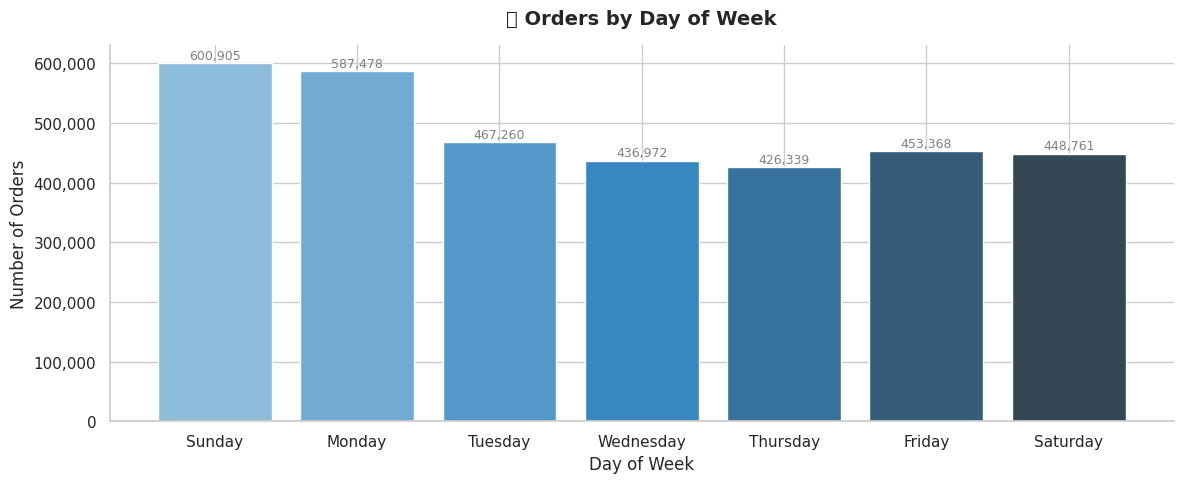

💡 Insight: Sunday and Monday are peak order days — customers stock up for the week.


In [9]:
dow_map = {0: "Sunday", 1: "Monday", 2: "Tuesday",
           3: "Wednesday", 4: "Thursday", 5: "Friday", 6: "Saturday"}
orders["day_name"] = orders["order_dow"].map(dow_map)

dow_counts = (
    orders.groupby(["order_dow", "day_name"])
    .size()
    .reset_index(name="order_count")
    .sort_values("order_dow")
)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(dow_counts["day_name"], dow_counts["order_count"],
              color=sns.color_palette("Blues_d", 7))
ax.set_title("📅 Orders by Day of Week", pad=15)
ax.set_xlabel("Day of Week")
ax.set_ylabel("Number of Orders")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Annotate bars
for bar, count in zip(bars, dow_counts["order_count"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f"{count:,}", ha="center", va="bottom", fontsize=9, color="gray")

plt.tight_layout()
plt.savefig("01_orders_by_dow.png", dpi=150, bbox_inches="tight")
plt.show()
print("💡 Insight: Sunday and Monday are peak order days — customers stock up for the week.")

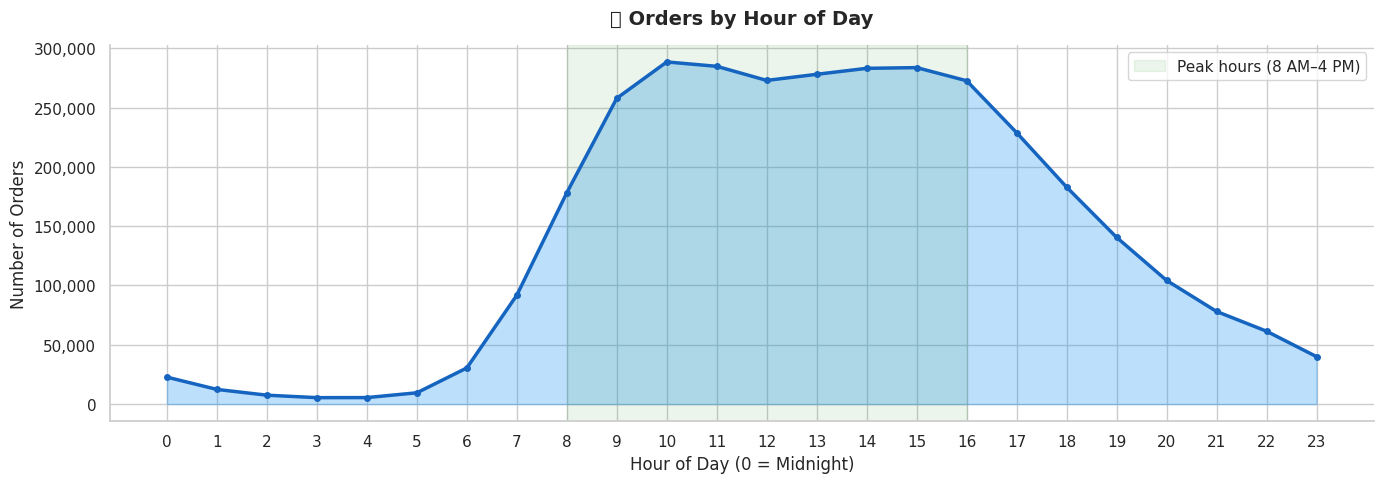

💡 Insight: 10 AM is the single peak hour. Ordering is minimal between midnight and 6 AM.


In [10]:
hour_counts = orders.groupby("order_hour_of_day").size().reset_index(name="order_count")

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(hour_counts["order_hour_of_day"], hour_counts["order_count"],
                alpha=0.3, color="#2196F3")
ax.plot(hour_counts["order_hour_of_day"], hour_counts["order_count"],
        color="#1565C0", linewidth=2.5, marker="o", markersize=4)
ax.set_title("🕐 Orders by Hour of Day", pad=15)
ax.set_xlabel("Hour of Day (0 = Midnight)")
ax.set_ylabel("Number of Orders")
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.axvspan(8, 16, alpha=0.08, color="green", label="Peak hours (8 AM–4 PM)")
ax.legend()
plt.tight_layout()
plt.savefig("01_orders_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()
print("💡 Insight: 10 AM is the single peak hour. Ordering is minimal between midnight and 6 AM.")

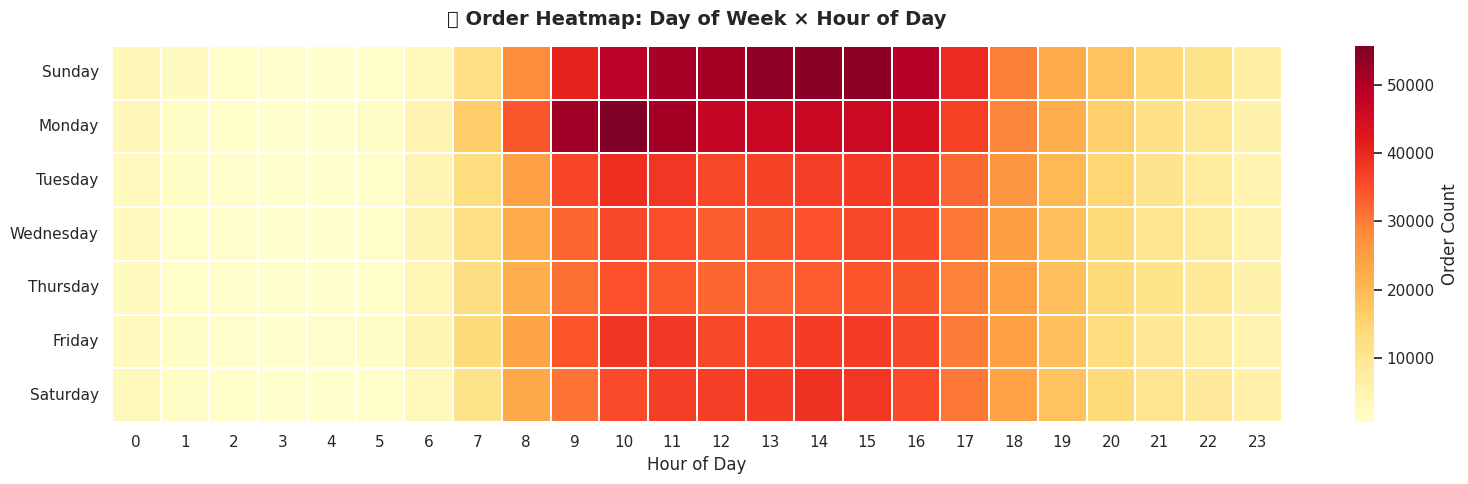

💡 Insight: Sunday 10 AM is the hottest slot. Late night ordering is rare across all days.


In [11]:
heatmap_data = (
    orders.groupby(["order_dow", "order_hour_of_day"])
    .size()
    .reset_index(name="count")
    .pivot(index="order_dow", columns="order_hour_of_day", values="count")
)
heatmap_data.index = [dow_map[i] for i in heatmap_data.index]

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap="YlOrRd", ax=ax, linewidths=0.3,
            fmt=",d", annot=False, cbar_kws={"label": "Order Count"})
ax.set_title("🔥 Order Heatmap: Day of Week × Hour of Day", pad=15)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("01_heatmap_dow_hour.png", dpi=150, bbox_inches="tight")
plt.show()
print("💡 Insight: Sunday 10 AM is the hottest slot. Late night ordering is rare across all days.")

In [12]:
print("""
╔══════════════════════════════════════════════════╗
║   SECTION 2: ORDER FREQUENCY & REORDER BEHAVIOR ║
╚══════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════╗
║   SECTION 2: ORDER FREQUENCY & REORDER BEHAVIOR ║
╚══════════════════════════════════════════════════╝



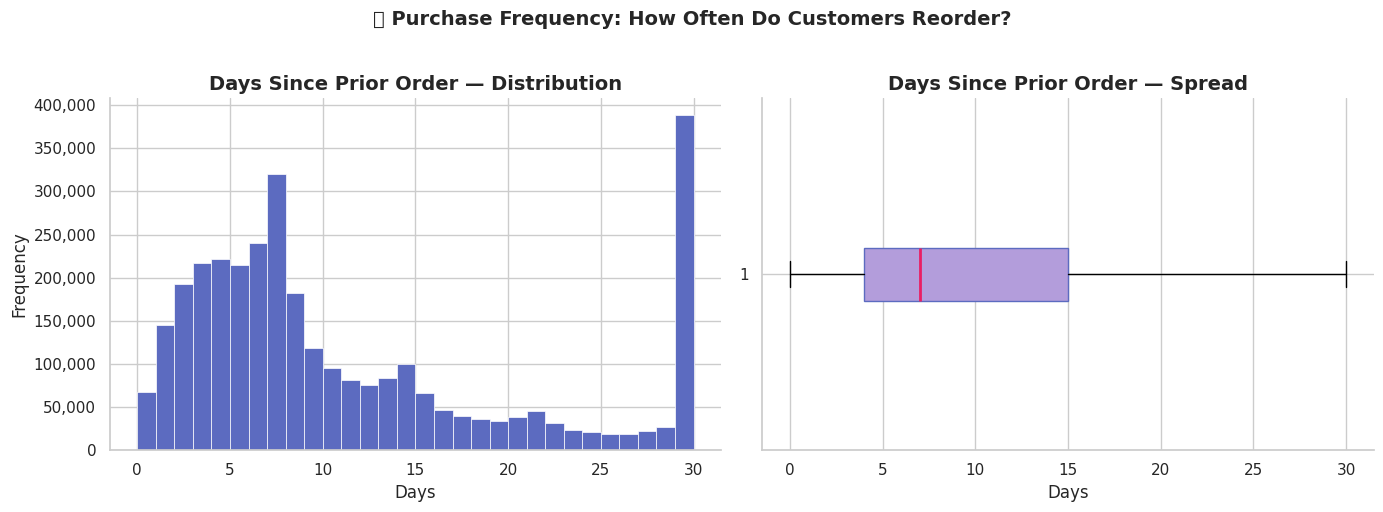

📊 Median days between orders: 7 days
📊 Mean days between orders:   11.1 days
💡 Insight: Strong spike at 7 days (weekly shoppers) and 30 days (monthly).


In [13]:
days_data = orders["days_since_prior_order"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(days_data, bins=30, color="#5C6BC0", edgecolor="white", linewidth=0.5)
axes[0].set_title("Days Since Prior Order — Distribution")
axes[0].set_xlabel("Days")
axes[0].set_ylabel("Frequency")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Box plot
axes[1].boxplot(days_data, vert=False, patch_artist=True,
                boxprops=dict(facecolor="#B39DDB", color="#5C6BC0"),
                medianprops=dict(color="#E91E63", linewidth=2))
axes[1].set_title("Days Since Prior Order — Spread")
axes[1].set_xlabel("Days")

plt.suptitle("🔄 Purchase Frequency: How Often Do Customers Reorder?",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("01_days_since_prior.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"📊 Median days between orders: {days_data.median():.0f} days")
print(f"📊 Mean days between orders:   {days_data.mean():.1f} days")
print(f"💡 Insight: Strong spike at 7 days (weekly shoppers) and 30 days (monthly).")

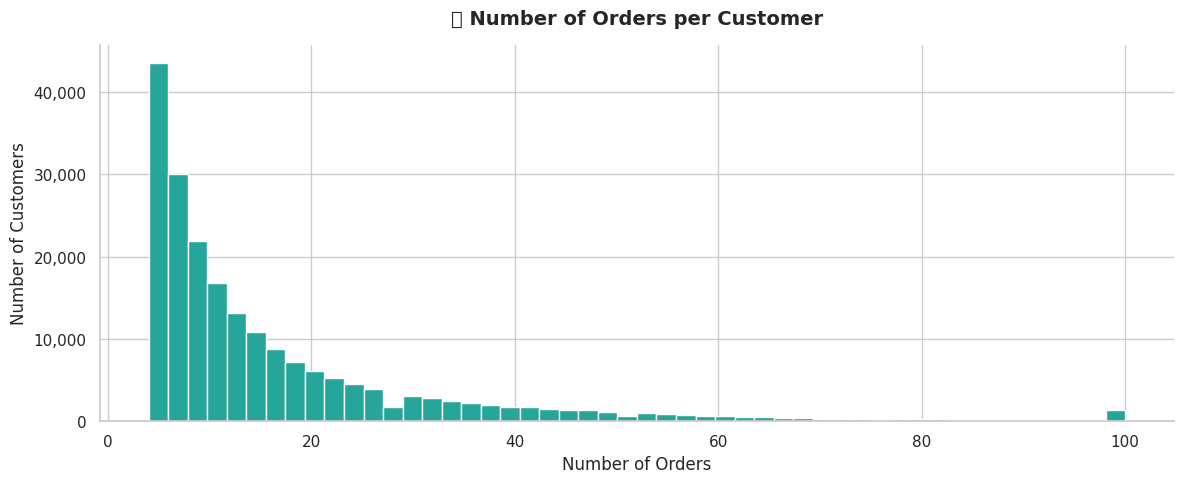

📊 Avg orders per user:  16.6
📊 Max orders per user:  100
💡 Insight: Most customers have 5–15 orders. Power users with 50+ orders exist.


In [14]:
orders_per_user = orders.groupby("user_id")["order_id"].count()

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(orders_per_user, bins=50, color="#26A69A", edgecolor="white")
ax.set_title("📦 Number of Orders per Customer", pad=15)
ax.set_xlabel("Number of Orders")
ax.set_ylabel("Number of Customers")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("01_orders_per_user.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"📊 Avg orders per user:  {orders_per_user.mean():.1f}")
print(f"📊 Max orders per user:  {orders_per_user.max()}")
print("💡 Insight: Most customers have 5–15 orders. Power users with 50+ orders exist.")

In [15]:
reorder_rate = all_order_products["reordered"].mean()
print(f"\n🔁 Overall reorder rate: {reorder_rate:.1%}")
print("💡 ~59% of all products added to a cart are reorders — loyalty is high.")


🔁 Overall reorder rate: 59.0%
💡 ~59% of all products added to a cart are reorders — loyalty is high.


In [16]:
print("""
╔══════════════════════════════════════════════════╗
║   SECTION 3: POPULAR PRODUCTS & CATEGORIES      ║
╚══════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════╗
║   SECTION 3: POPULAR PRODUCTS & CATEGORIES      ║
╚══════════════════════════════════════════════════╝



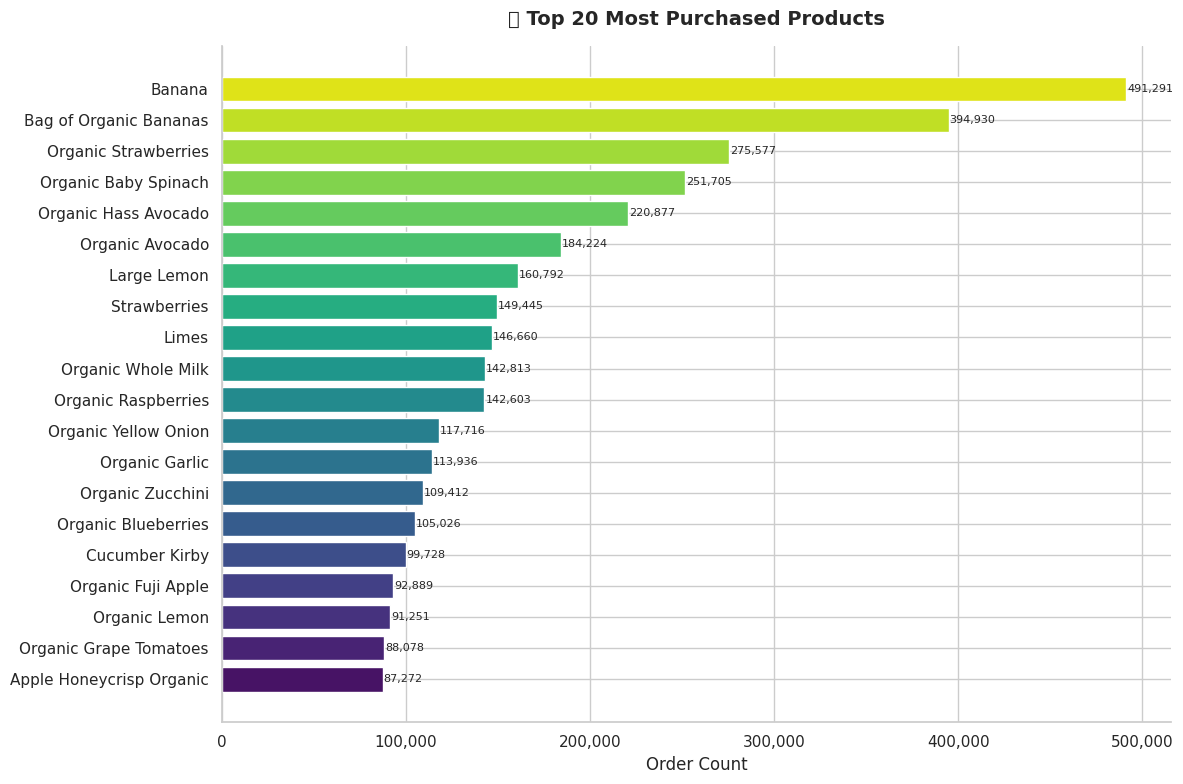

💡 Insight: Bananas dominate by a wide margin. Organic produce is heavily favored.


In [17]:
top_products = (
    order_detail.groupby("product_name")["order_id"]
    .count()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
    .rename(columns={"order_id": "order_count"})
)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top_products["product_name"][::-1],
               top_products["order_count"][::-1],
               color=sns.color_palette("viridis", 20))
ax.set_title("🥇 Top 20 Most Purchased Products", pad=15)
ax.set_xlabel("Order Count")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, count in zip(bars, top_products["order_count"][::-1]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f"{count:,}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("01_top20_products.png", dpi=150, bbox_inches="tight")
plt.show()
print("💡 Insight: Bananas dominate by a wide margin. Organic produce is heavily favored.")

In [18]:
top_aisles = (
    order_detail.groupby("aisle")["order_id"]
    .count()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
    .rename(columns={"order_id": "order_count"})
)

fig = px.bar(top_aisles, x="order_count", y="aisle",
             orientation="h", title="🛒 Top 15 Most Popular Aisles",
             color="order_count", color_continuous_scale="Blues",
             labels={"order_count": "Order Count", "aisle": "Aisle"},
             height=500)
fig.update_layout(yaxis={"categoryorder": "total ascending"},
                  coloraxis_showscale=False)
fig.show()
print("💡 Insight: Fresh vegetables, fresh fruits, and packaged vegetables/fruits are the top 3.")

💡 Insight: Fresh vegetables, fresh fruits, and packaged vegetables/fruits are the top 3.


In [19]:
dept_counts = (
    order_detail.groupby("department")["order_id"]
    .count()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"order_id": "order_count"})
)

fig = px.pie(dept_counts, names="department", values="order_count",
             title="🏪 Orders by Department",
             hole=0.4,
             color_discrete_sequence=px.colors.qualitative.Set3)
fig.update_traces(textposition="outside", textinfo="label+percent")
fig.update_layout(showlegend=False, height=550)
fig.show()
print("💡 Insight: Produce accounts for ~25% of all orders. Dairy & deli follow.")

💡 Insight: Produce accounts for ~25% of all orders. Dairy & deli follow.


In [20]:
print("""
╔══════════════════════════════════════════════════╗
║   SECTION 4: BASKET SIZE ANALYSIS               ║
╚══════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════╗
║   SECTION 4: BASKET SIZE ANALYSIS               ║
╚══════════════════════════════════════════════════╝



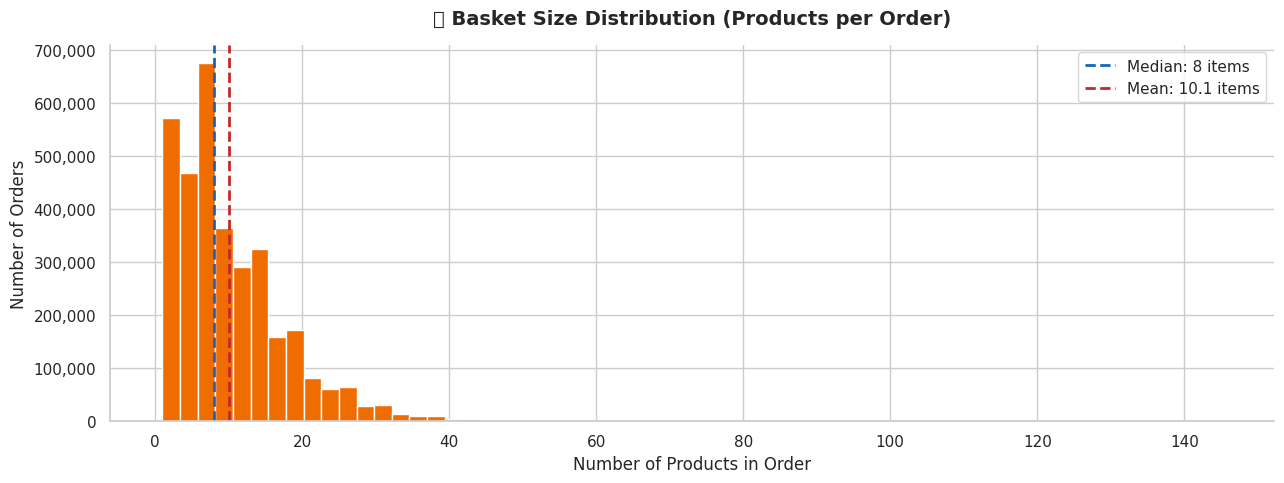

📊 Median basket size: 8 items
📊 Mean basket size:   10.1 items
📊 Max basket size:    145 items
💡 Insight: Most orders contain 5–10 items. Some mega-baskets with 50+ items exist.


In [21]:
basket_sizes = (
    all_order_products.groupby("order_id")["product_id"]
    .count()
    .reset_index()
    .rename(columns={"product_id": "basket_size"})
)

fig, ax = plt.subplots(figsize=(13, 5))
ax.hist(basket_sizes["basket_size"], bins=60, color="#EF6C00", edgecolor="white")
ax.axvline(basket_sizes["basket_size"].median(), color="#1565C0",
           linestyle="--", linewidth=2, label=f"Median: {basket_sizes['basket_size'].median():.0f} items")
ax.axvline(basket_sizes["basket_size"].mean(), color="#C62828",
           linestyle="--", linewidth=2, label=f"Mean: {basket_sizes['basket_size'].mean():.1f} items")
ax.set_title("🧺 Basket Size Distribution (Products per Order)", pad=15)
ax.set_xlabel("Number of Products in Order")
ax.set_ylabel("Number of Orders")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("01_basket_size.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"📊 Median basket size: {basket_sizes['basket_size'].median():.0f} items")
print(f"📊 Mean basket size:   {basket_sizes['basket_size'].mean():.1f} items")
print(f"📊 Max basket size:    {basket_sizes['basket_size'].max()} items")
print("💡 Insight: Most orders contain 5–10 items. Some mega-baskets with 50+ items exist.")

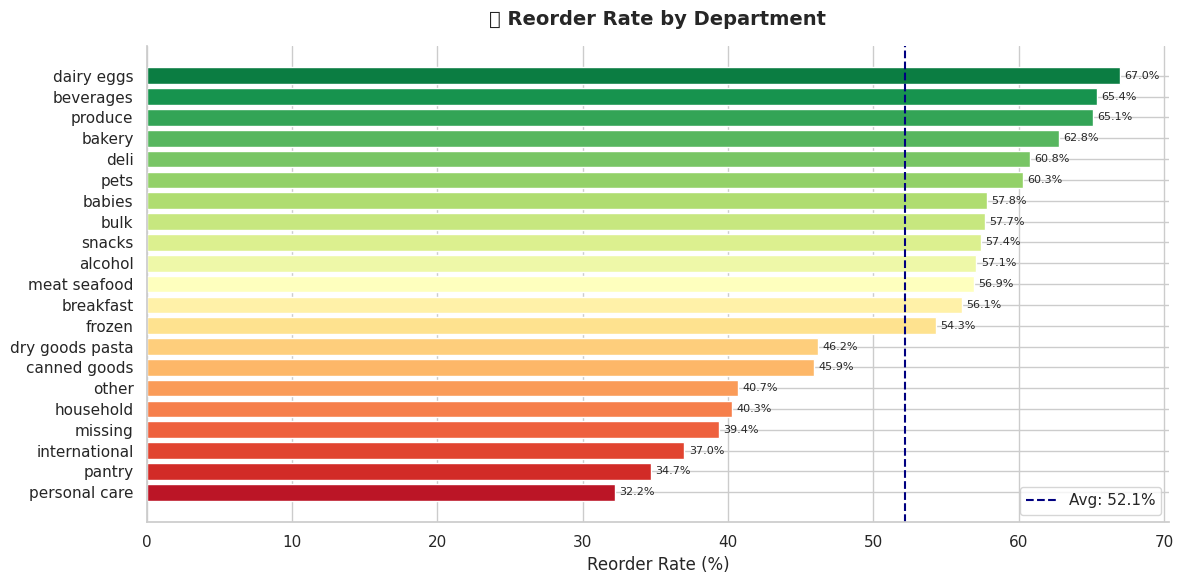

💡 Insight: Personal care has the highest reorder rate — habitual purchases. Bulk/alcohol lower.


In [22]:
dept_reorder = (
    order_detail.groupby("department")["reordered"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"reordered": "reorder_rate"})
)
dept_reorder["reorder_rate_pct"] = (dept_reorder["reorder_rate"] * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(dept_reorder["department"][::-1],
               dept_reorder["reorder_rate_pct"][::-1],
               color=sns.color_palette("RdYlGn", len(dept_reorder)))
ax.set_title("🔁 Reorder Rate by Department", pad=15)
ax.set_xlabel("Reorder Rate (%)")
ax.axvline(dept_reorder["reorder_rate_pct"].mean(), color="navy",
           linestyle="--", linewidth=1.5, label=f"Avg: {dept_reorder['reorder_rate_pct'].mean():.1f}%")
ax.legend()
for bar, val in zip(bars, dept_reorder["reorder_rate_pct"][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val}%", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("01_reorder_by_dept.png", dpi=150, bbox_inches="tight")
plt.show()
print("💡 Insight: Personal care has the highest reorder rate — habitual purchases. Bulk/alcohol lower.")

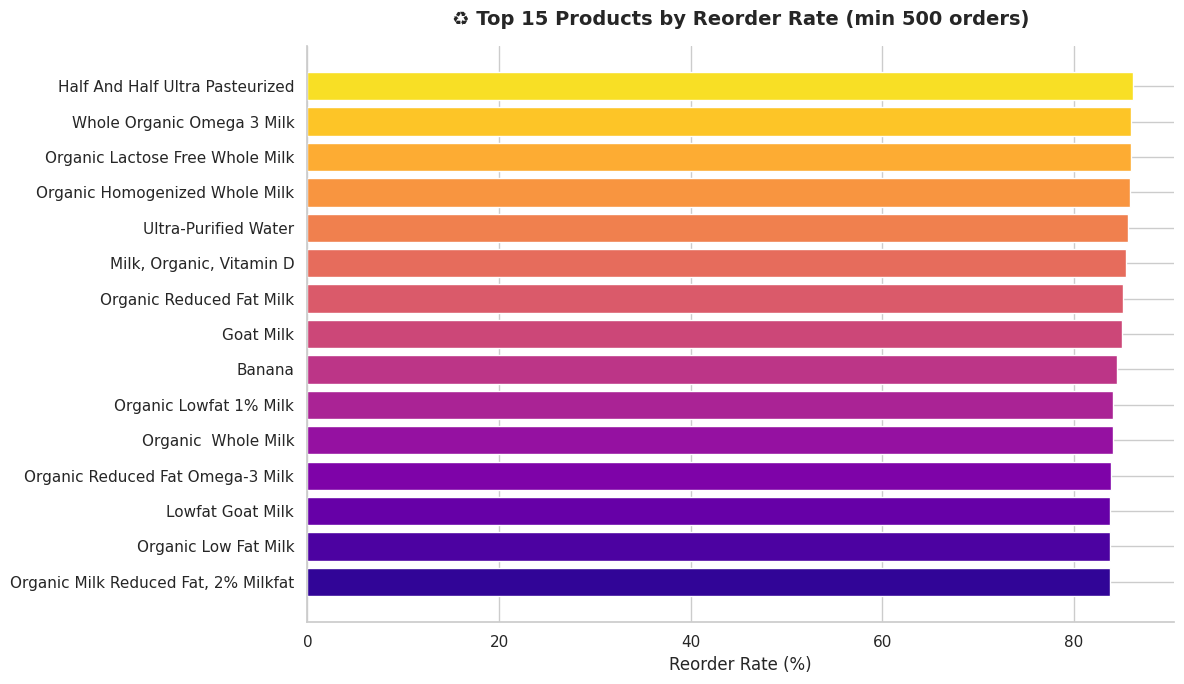

💡 Insight: Ice cream and specialty beverages have near-90% reorder rates — strong loyalty items.


In [23]:
top_reordered = (
    order_detail.groupby("product_name")["reordered"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "reorder_rate", "count": "total_orders"})
    .query("total_orders >= 500")
    .sort_values("reorder_rate", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_reordered["product_name"][::-1],
               (top_reordered["reorder_rate"][::-1] * 100),
               color=sns.color_palette("plasma", 15))
ax.set_title("♻️ Top 15 Products by Reorder Rate (min 500 orders)", pad=15)
ax.set_xlabel("Reorder Rate (%)")
plt.tight_layout()
plt.savefig("01_top_reordered_products.png", dpi=150, bbox_inches="tight")
plt.show()
print("💡 Insight: Ice cream and specialty beverages have near-90% reorder rates — strong loyalty items.")

In [25]:
print("""
╔══════════════════════════════════════════════════════╗
║   EDA SUMMARY — KEY FINDINGS                         ║
╚══════════════════════════════════════════════════════╝

🗓️  TIMING
   • Peak day:   Sunday & Monday (~600K+ orders each)
   • Peak hour:  10 AM across all days
   • Hot slot:   Sunday 10 AM is the single busiest window

🔄  REORDER BEHAVIOR
   • Overall reorder rate: ~59%
   • Most common reorder cadence: 7 days (weekly shoppers)
   • Personal care items have highest reorder rates (~80%)

🛒  PRODUCTS & CATEGORIES
   • #1 product: Bananas (by a large margin)
   • Top department: Produce (~25% of all orders)
   • Organic products appear heavily in top 20

🧺  BASKET SIZE
   • Median: ~8 items per order
   • Mean: ~10 items per order
   • Long tail of 30–50+ item baskets

➡️  NEXT: Notebook 02 — Feature Engineering
""")


╔══════════════════════════════════════════════════════╗
║   EDA SUMMARY — KEY FINDINGS                         ║
╚══════════════════════════════════════════════════════╝

🗓️  TIMING
   • Peak day:   Sunday & Monday (~600K+ orders each)
   • Peak hour:  10 AM across all days
   • Hot slot:   Sunday 10 AM is the single busiest window

🔄  REORDER BEHAVIOR
   • Overall reorder rate: ~59%
   • Most common reorder cadence: 7 days (weekly shoppers)
   • Personal care items have highest reorder rates (~80%)

🛒  PRODUCTS & CATEGORIES
   • #1 product: Bananas (by a large margin)
   • Top department: Produce (~25% of all orders)
   • Organic products appear heavily in top 20

🧺  BASKET SIZE
   • Median: ~8 items per order
   • Mean: ~10 items per order
   • Long tail of 30–50+ item baskets

➡️  NEXT: Notebook 02 — Feature Engineering

